In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [6]:
df = pd.read_csv("deliveries.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (260920, 17)
   match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ganguly             0           1   
3     4  BB McCullum  P Kumar   SC Ganguly             0           0   
4     5  BB McCullum  P Kumar   SC Ganguly             0           0   

   total_runs extras_type  is_wicket player_dismisse

In [7]:
print("Column Names:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Column Names:
Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')

Missing Values:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [21]:
features = ['inning','over','ball','batting_team','bowling_team','batter','bowler','non_striker']
X = df[features]
y = df['is_wicket']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (260920, 8)
Target Shape: (260920,)


In [22]:
categorical_features = ['batting_team','bowling_team','batter','bowler','non_striker']
numeric_features = ['inning','over','ball']


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

X_processed = preprocessor.fit_transform(X)

In [24]:
print("Original Shape:", X.shape)
print("Processed Shape:", X_processed.shape)

Original Shape: (260920, 8)
Processed Shape: (260920, 1907)


In [10]:
print("Target Values:")
print(y.value_counts())

Target Values:
is_wicket
0    247970
1     12950
Name: count, dtype: int64


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_processed,y,test_size=0.20,random_state=42,stratify=y)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (208736, 1907)
Testing Data: (52184, 1907)


In [26]:
lr_model = LogisticRegression(max_iter=1000,random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9503679288670857

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     49594
           1       0.00      0.00      0.00      2590

    accuracy                           0.95     52184
   macro avg       0.48      0.50      0.49     52184
weighted avg       0.90      0.95      0.93     52184



c:\Users\fathima shaura\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fathima shaura\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fathima shaura\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

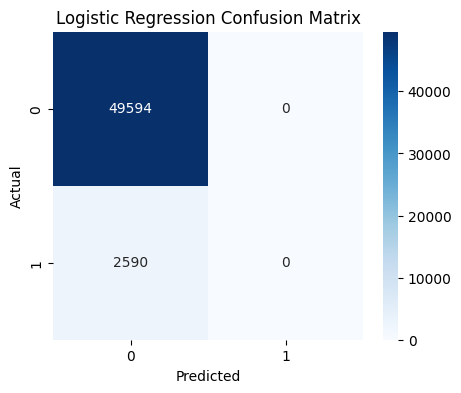

In [29]:
lr_cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(lr_cm,annot=True,fmt='d',cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [14]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9498505288977465

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     49594
           1       0.09      0.00      0.00      2590

    accuracy                           0.95     52184
   macro avg       0.52      0.50      0.49     52184
weighted avg       0.91      0.95      0.93     52184



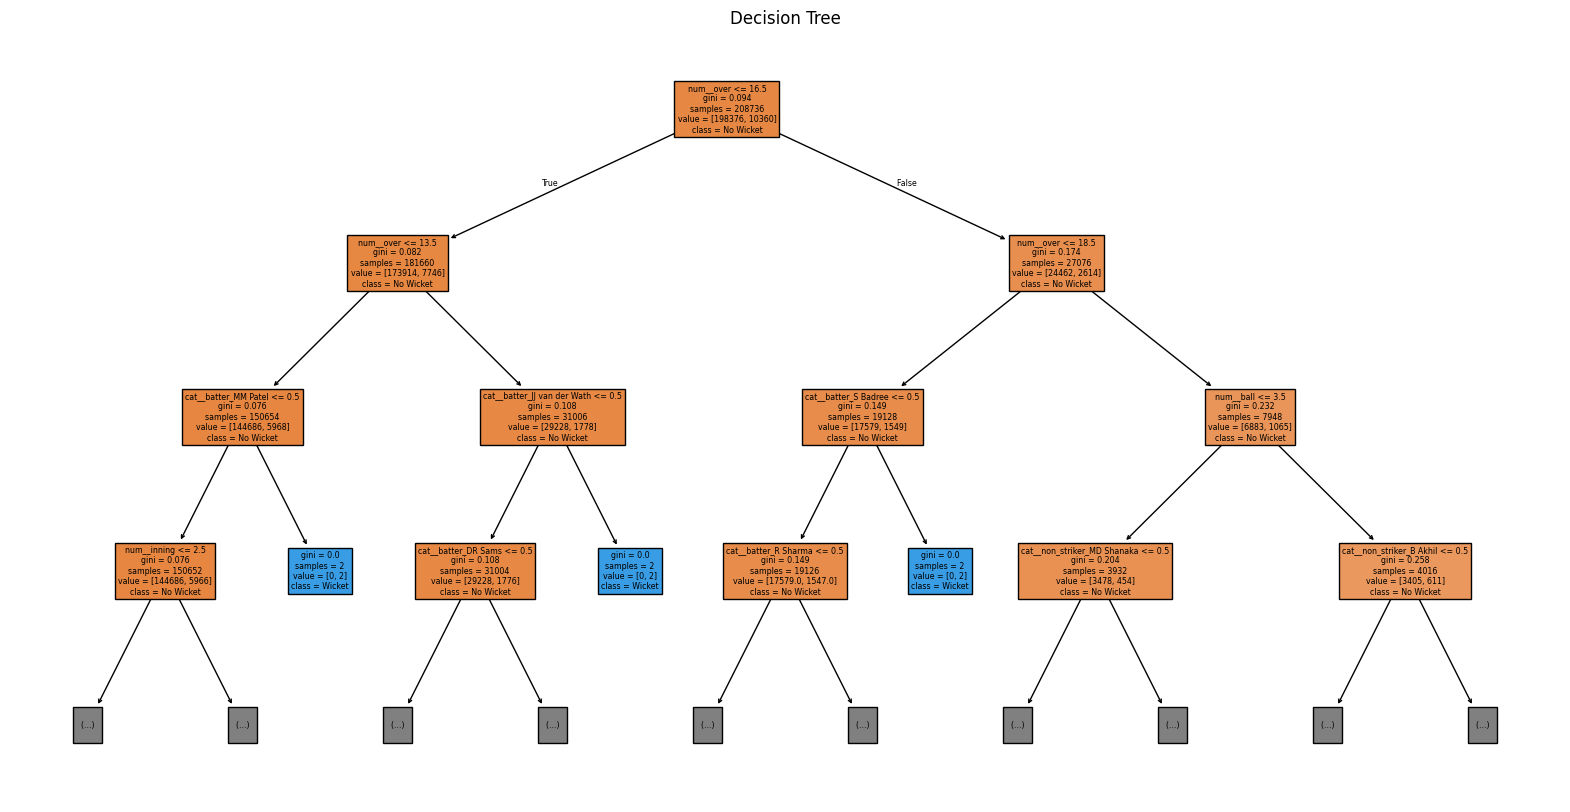

In [31]:
plt.figure(figsize=(20, 10))

plot_tree(
    dt_model,
    max_depth=3,
    filled=True,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=['No Wicket', 'Wicket']
)

plt.title("Decision Tree")
plt.show()

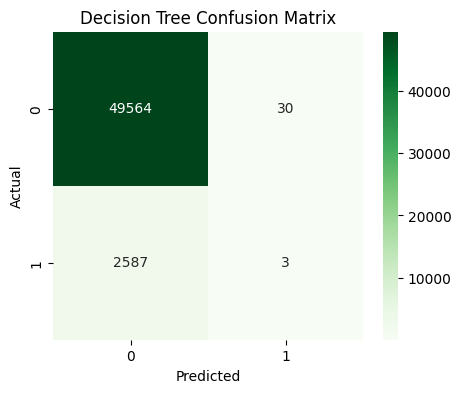

In [15]:
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9503679288670857

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97     49594
           1       0.00      0.00      0.00      2590

    accuracy                           0.95     52184
   macro avg       0.48      0.50      0.49     52184
weighted avg       0.90      0.95      0.93     52184



c:\Users\fathima shaura\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fathima shaura\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\fathima shaura\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control thi

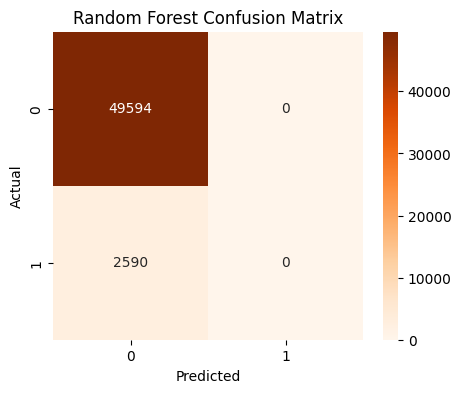

In [17]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
results = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

print(results)

             Algorithm  Accuracy
0  Logistic Regression  0.950368
1        Decision Tree  0.949851
2        Random Forest  0.950368


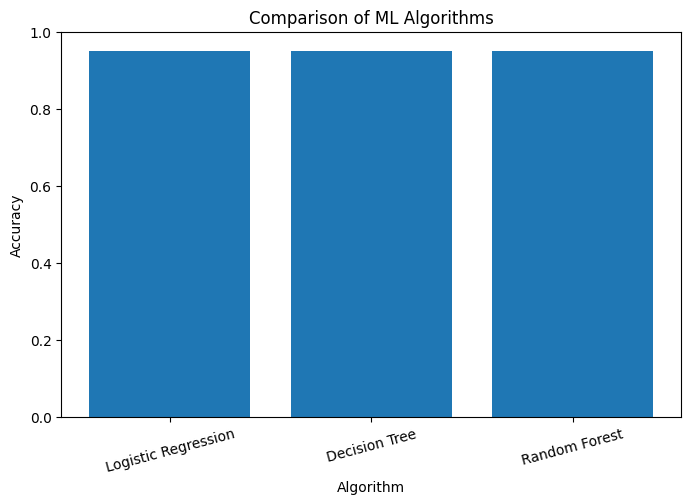

In [19]:
plt.figure(figsize=(8, 5))

plt.bar(
    results['Algorithm'],
    results['Accuracy']
)

plt.title("Comparison of ML Algorithms")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")

plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.show()

In [20]:
best_algorithm = results.loc[
    results['Accuracy'].idxmax(),
    'Algorithm'
]

best_accuracy = results['Accuracy'].max()

print("Best Performing Algorithm:", best_algorithm)
print("Best Accuracy:", best_accuracy)

Best Performing Algorithm: Logistic Regression
Best Accuracy: 0.9503679288670857
